In [19]:
import yfinance as yf
import pandas as pd
import numpy as np

TICKERS = [
    # US Core
    "SPY","IVV","VOO","QQQ","VTI","ITOT","DIA","IWM","IJR","MDY",
    # Styles / Factors
    "VUG","IWF","VTV","IWD","SCHD","VIG","DVY","MTUM","QUAL","USMV","VLUE",
    # Sectors
    "XLK","XLF","XLV","XLY","XLP","XLE","XLI","XLU","XLB","XLRE",
    # International
    "VEA","IEFA","VWO","IEMG","EFA","EEM","EWJ","EWG","EWU","EWQ",
    "INDA","EWZ","FXI","MCHI","EWT","EWY",
    # Bonds
    "BND","AGG","IEF","TLT","SHY","LQD","HYG","JNK","TIP","BIL",
    # Commodities / REITs
    "GLD","IAU","SLV","USO","DBC","VNQ",
]




In [20]:
# Descargar datos históricos
data = yf.download(TICKERS, start="2019-01-01", auto_adjust=False, progress=False)


In [21]:
variables = data.columns.get_level_values(0).unique()
variables


Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')

In [22]:
for v in variables:
    print(v, data[v].shape)


Adj Close (1777, 63)
Close (1777, 63)
High (1777, 63)
Low (1777, 63)
Open (1777, 63)
Volume (1777, 63)


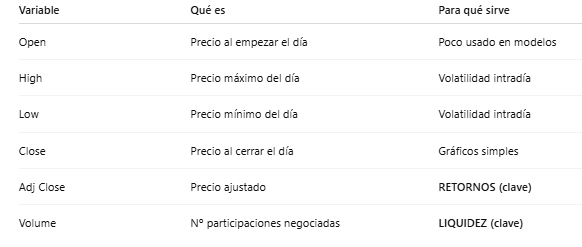

In [ ]:

#Precios y volumen histórico
adj = data["Adj Close"].copy()
vol = data["Volume"].copy() #cuántas participaciones se han comprado/vendido ese día

# Close = último precio del día
# Adj Close = precio ajustado por dividendos y splits
print("Adj Close shape:", adj.shape)
print("Volume shape:", vol.shape)

# Vista básica
display(adj.head()) 
# Cada columna = un ETF
# Cada fila = un día de mercado
# Cada celda = precio ajustado de ese ETF ese día
display(vol.head())


Adj Close shape: (1777, 63)
Volume shape: (1777, 63)


Ticker,AGG,BIL,BND,DBC,DIA,DVY,EEM,EFA,EWG,EWJ,...,XLB,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-02,87.471397,76.579811,64.730515,12.443766,204.362274,68.605133,33.319092,47.469452,21.159798,43.776043,...,22.028011,21.261765,21.041233,57.592129,29.068298,41.901951,23.986851,20.903225,75.582733,46.748016
2019-01-03,87.832512,76.604950,64.983345,12.546535,198.547256,67.980812,32.715004,47.040565,20.882269,43.527313,...,21.403345,21.050896,20.568197,55.839622,27.601290,41.661224,24.097719,20.899210,74.048004,45.735825
2019-01-04,87.569847,76.613304,64.787560,12.717820,205.167831,69.614815,33.770042,48.480988,21.664408,45.002525,...,22.244902,21.767136,21.251465,57.956852,28.824577,42.549404,24.343204,21.208677,76.256927,47.249424
2019-01-07,87.422119,76.613304,64.689758,12.812025,206.113647,70.023308,33.846619,48.667107,21.698046,45.114029,...,22.322990,22.090712,21.277748,58.428337,29.082359,42.491291,24.549105,21.063992,76.549690,48.317848
2019-01-08,87.356453,76.613304,64.608200,12.940489,208.355576,70.747826,33.974247,48.982719,21.832609,45.328442,...,22.557234,22.261591,21.295263,59.228966,29.326080,42.881435,24.976734,21.325232,77.144051,48.852051


Ticker,AGG,BIL,BND,DBC,DIA,DVY,EEM,EFA,EWG,EWJ,...,XLB,XLE,XLF,XLI,XLK,XLP,XLRE,XLU,XLV,XLY
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-02,11200700,15671600,4142500,2071100,5319500,1199700,57198800,38723200,3756500,12513000,...,18192600,49785200,62945000,14687500,30885800,20459000,10445000,50347800,14179900,13681600
2019-01-03,6497000,3316200,4908400,1389700,7350200,1032200,62767600,35012600,5076000,10740200,...,19668000,36048200,65729700,25976200,49893400,22074800,9743800,43175000,17668000,12692000
2019-01-04,8149000,5483000,4583600,1332200,7343700,1628100,103055100,47001700,5316800,18702400,...,17901200,42703000,64638400,19883600,41535600,19003300,9620900,38007000,16262600,14538200
2019-01-07,7433700,2840200,4121700,1581700,5101600,1961800,76597000,30335900,4559000,8639900,...,14936600,36113400,48167000,15193100,23817200,15143300,5141800,32535400,12387200,12526200
2019-01-08,4395600,1923100,1745400,1741600,4845800,885900,70518200,26444600,4335100,7369700,...,20657200,37384600,90114700,23069500,26005200,28273800,7575900,33287000,13371000,18782000


In [ ]:

# Nulos por ticker (para saber si tienen dias sin datos dentro de cada etf)
nan_ratio = adj.isna().mean().sort_values(ascending=False)
display(nan_ratio.head(15))

# Tickers que han bajado bien (pocos NaNs)
good = nan_ratio[nan_ratio <= 0.05].index.tolist()
print("Tickers con <=5% NaNs:", len(good))


Ticker
AGG    0.0
BIL    0.0
BND    0.0
DBC    0.0
DIA    0.0
DVY    0.0
EEM    0.0
EFA    0.0
EWG    0.0
EWJ    0.0
EWQ    0.0
EWT    0.0
EWU    0.0
EWY    0.0
EWZ    0.0
dtype: float64

Tickers con <=5% NaNs: 63


El objetivo de este proyecto es analizar si predicciones aproximadas de ganancias y riesgo diario pueden ayudar a decidir mejor cómo gestionar una cartera de inversión, teniendo en cuenta los costes de compra y venta y la posibilidad de mantener la cartera sin cambios.

Para que la cartera sea realista, se analiza la liquidez de los ETFs mediante el volumen diario negociado en dólares, ya que indica cuánto dinero real se mueve cada día en el mercado. Se eliminan los ETFs con poco volumen porque son más difíciles y caros de comprar o vender. Para ello, se fija un volumen mínimo diario como umbral, que permite trabajar solo con activos suficientemente líquidos.

In [27]:
# Dollar Volume diario = precio ajustado × volumen
dollar_vol = adj * vol


In [28]:
median_dollar_vol = dollar_vol.median()
liquidity_table = median_dollar_vol.sort_values(ascending=False)
display(liquidity_table) #ver de más 


Ticker
SPY     2.909415e+10
QQQ     1.520116e+10
IWM     5.020270e+09
HYG     2.063519e+09
TLT     2.028767e+09
            ...     
EWU     5.990052e+07
DVY     5.526714e+07
VLUE    4.283950e+07
DBC     2.075453e+07
EWQ     1.693548e+07
Length: 63, dtype: float64

In [29]:
threshold = 10_000_000  # 10 millones USD
selected = liquidity_table[liquidity_table >= threshold]

print("ETFs antes:", len(liquidity_table))
print("ETFs después:", len(selected))




ETFs antes: 63
ETFs después: 63


Todos los ETFs considerados presentan un volumen diario negociado en dólares superior al umbral mínimo establecido, por lo que no fue necesario excluir ninguno por motivos de liquidez.

CALCULAMOS LOS RETORNOS SIMPLES

(hoy − ayer) / ayer


In [ ]:
# Retorno simple y logarítmico
returns = pd.concat(
    {
        "retorno_simple": adj.pct_change(),
        "retorno_log": np.log(adj).diff()
    },
    axis=1
).dropna()
